<a href="https://colab.research.google.com/github/2003Himansh/Data-Analysis-Portfolio/blob/main/Healthcare_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required Python libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
# Import important libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning library
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Set visualization style
sns.set_style("whitegrid")

In [ ]:
# Read the dataset
df = pd.read_csv("/content/healthcare_dataset.csv")

# Display first 5 rows
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Show column names
print("\nColumns:")
print(df.columns)

# Display dataset information
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (27707, 15)

Columns:
Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27707 entries, 0 to 27706
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                27707 non-null  object 
 1   Age                 27707 non-null  int64  
 2   Gender              27707 non-null  object 
 3   Blood Type          27707 non-null  object 
 4   Medical Condition   27707 non-null  object 
 5   Date of Admission   27707 non-null  object 
 6   Doctor              27707 non-null  object 
 7   Hospital            27707 non-null  object 
 8   Insurance Provider  27707 non-null  object 
 9   Billing Amount      

In [ ]:
# Check for missing values in each column
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [ ]:
# Remove missing values
df = df.dropna()

In [ ]:
# Convert admission date to datetime format
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])

# Convert discharge date to datetime format
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [ ]:
# Calculate hospital stay duration
df['Hospital Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

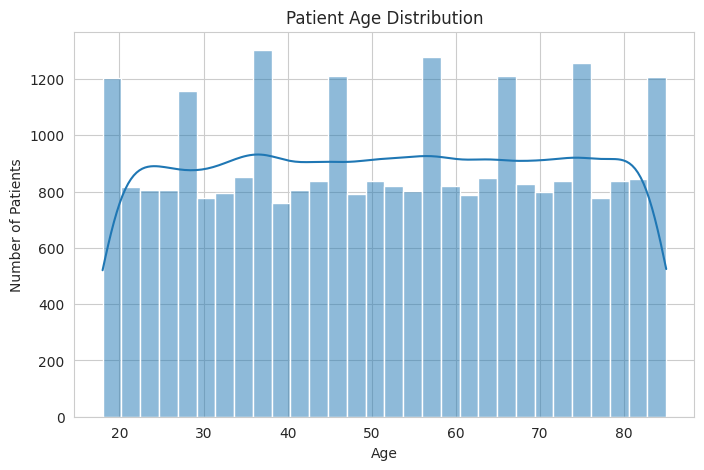

In [ ]:
#Patient age distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

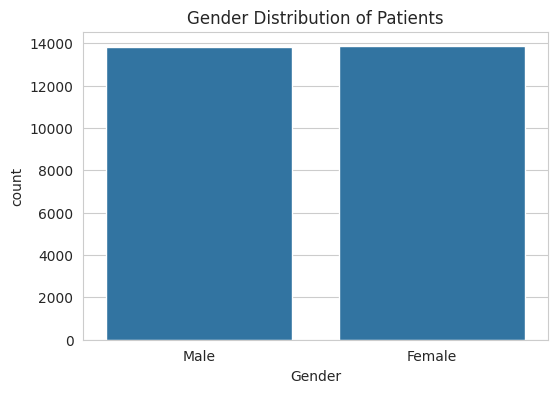

In [ ]:
#gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution of Patients")
plt.show()

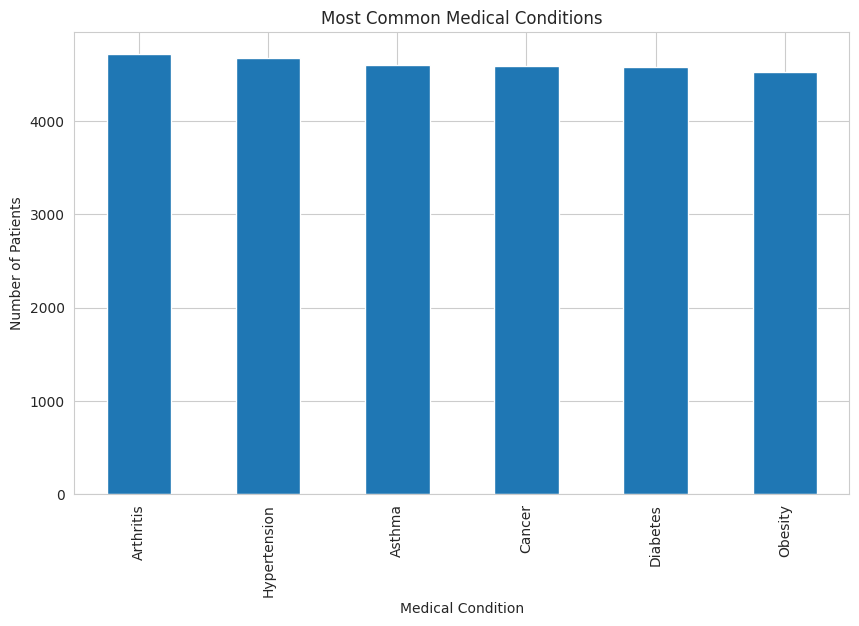

In [ ]:
#Medical Condition Frequency
plt.figure(figsize=(10,6))

df['Medical Condition'].value_counts().plot(kind='bar')

plt.title("Most Common Medical Conditions")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")

plt.show()

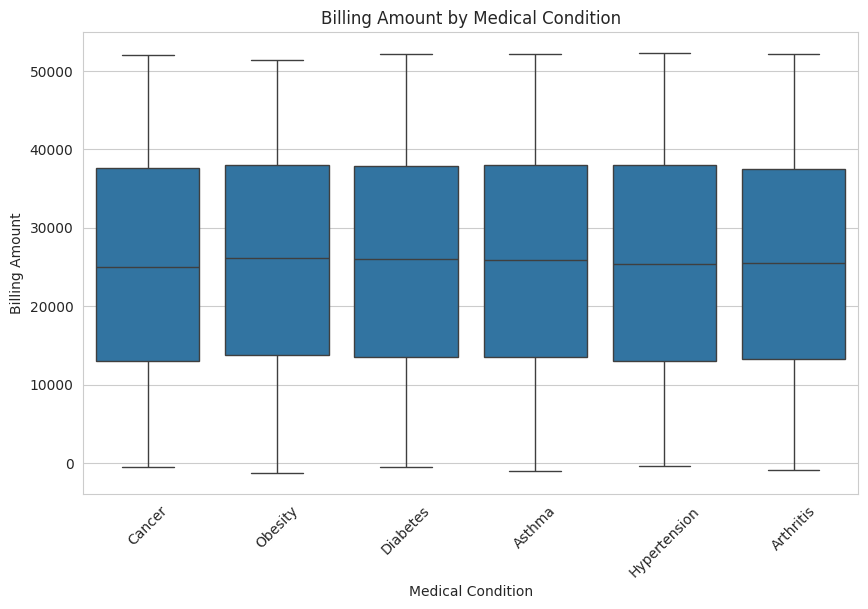

In [ ]:
#Billing Amount by Condition
plt.figure(figsize=(10,6))

sns.boxplot(x='Medical Condition', y='Billing Amount', data=df)

plt.xticks(rotation=45)

plt.title("Billing Amount by Medical Condition")

plt.show()

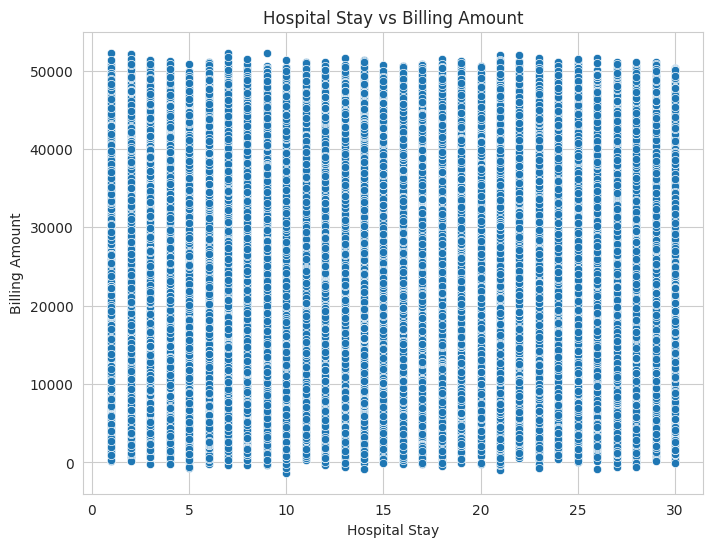

In [ ]:
#Hospital Stay vs Billing Amount
plt.figure(figsize=(8,6))

sns.scatterplot(x='Hospital Stay', y='Billing Amount', data=df)

plt.title("Hospital Stay vs Billing Amount")

plt.show()

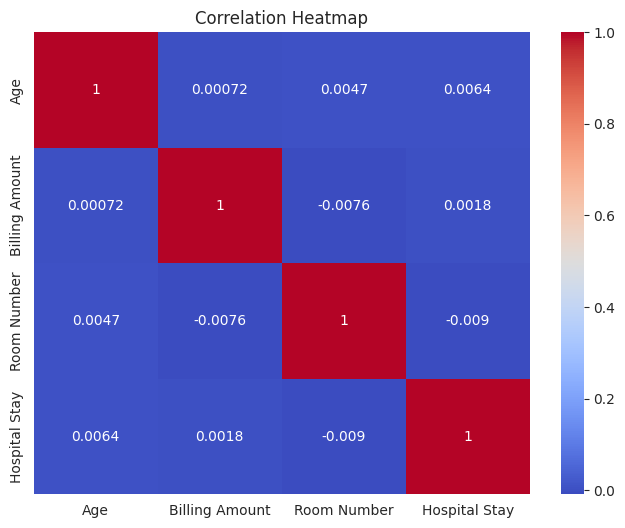

In [ ]:
#corellation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Average hospital stay
avg_stay = df['Hospital Stay'].mean()

# Average billing amount
avg_bill = df['Billing Amount'].mean()

# Maximum billing
max_bill = df['Billing Amount'].max()

print("Average Hospital Stay:", avg_stay)
print("Average Billing Amount:", avg_bill)
print("Maximum Billing Amount:", max_bill)

Average Hospital Stay: 15.488179882340203
Average Billing Amount: 25611.364889588596
Maximum Billing Amount: 52271.66374715383


In [ ]:
#machine learning prediction
# Select features
X = df[['Age', 'Hospital Stay']]

# Target variable
y = df['Billing Amount']

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict billing amount
y_pred = model.predict(X_test)

In [ ]:
# Calculate error
mae = mean_absolute_error(y_test, y_pred)

# R² score
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 12235.33891387222
R2 Score: -0.0006367775925983921


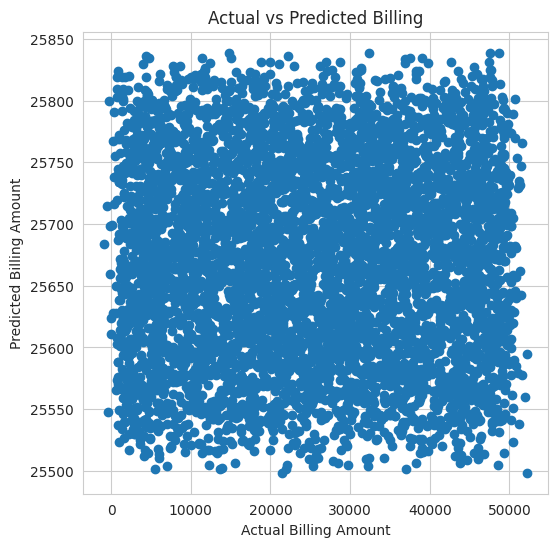

In [ ]:
#prediction visualization
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Billing Amount")
plt.ylabel("Predicted Billing Amount")

plt.title("Actual vs Predicted Billing")

plt.show()